# Task 2 - Rossmann Sales Forecasting: preprocessing, feature engineering, sklearn Pipeline + Random Forest, evaluation, feature importance, approximate prediction interval, model serialization, LSTM and MLflow.

In [ ]:
import os
import sys
import warnings
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# LOGGER
# Keep logger initialization independent of a local src package.
os.makedirs("logs", exist_ok=True)

logger = logging.getLogger("TASK_2")
logger.setLevel(logging.INFO)

if not logger.handlers:
    formatter = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )

    file_handler = logging.FileHandler(
        "logs/task2.log"
    )
    console_handler = logging.StreamHandler()

    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

logger.info("Task 2 started.")

2026-08-09 20:50:19,160 - TASK_2 - INFO - Task 2 started.


Imports and logger completed.


# Load and Merge Data

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

train = train.merge(
    store,
    on="Store",
    how="left"
)

test = test.merge(
    store,
    on="Store",
    how="left"
)

logger.info(f"Train shape after store merge: {train.shape}")
logger.info(f"Test shape after store merge: {test.shape}")

print("Train:", train.shape)
print("Test :", test.shape)
print("Store:", store.shape)

2026-08-09 20:50:22,840 - TASK_2 - INFO - Train shape after store merge: (1017209, 18)
2026-08-09 20:50:22,843 - TASK_2 - INFO - Test shape after store merge: (41088, 17)


Train: (1017209, 18)
Test : (41088, 17)
Store: (1115, 10)


# Missing Value Handling

In [ ]:
def handle_missing_values(data):
    data = data.copy()

    if "CompetitionDistance" in data.columns:
        data["CompetitionDistance"] = data["CompetitionDistance"].fillna(
            data["CompetitionDistance"].median()
        )

    for col in [
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear"
    ]:
        if col in data.columns:
            data[col] = data[col].fillna(0)

    if "PromoInterval" in data.columns:
        data["PromoInterval"] = data["PromoInterval"].fillna("None")

    if "Open" in data.columns:
        data["Open"] = data["Open"].fillna(1)

    return data


train = handle_missing_values(train)
test = handle_missing_values(test)

logger.info(
    f"Remaining train missing values: {train.isna().sum().sum()}"
)
logger.info(
    f"Remaining test missing values: {test.isna().sum().sum()}"
)

print("Train missing:", train.isna().sum().sum())
print("Test missing :", test.isna().sum().sum())

2026-08-09 20:50:24,090 - TASK_2 - INFO - Remaining train missing values: 0
2026-08-09 20:50:24,117 - TASK_2 - INFO - Remaining test missing values: 0


Train missing: 0
Test missing : 0


# Date, Holiday, Competition and Promo Features

In [ ]:
def add_date_features(data):
    data = data.copy()

    if "StateHoliday" in data.columns:
        data["StateHoliday"] = (
            data["StateHoliday"]
            .astype("string")
            .fillna("0")
            .astype(str)
        )

    # Date features
    data["DayOfWeek"] = data["Date"].dt.dayofweek
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)
    data["Quarter"] = data["Date"].dt.quarter
    data["DayOfYear"] = data["Date"].dt.dayofyear

    data["IsWeekend"] = (
        data["DayOfWeek"].isin([5, 6])
    ).astype(int)

    data["IsBeginningOfMonth"] = (
        data["Day"] <= 10
    ).astype(int)

    data["IsMidMonth"] = (
        data["Day"].between(11, 20)
    ).astype(int)

    data["IsEndOfMonth"] = (
        data["Day"] > 20
    ).astype(int)

    data["IsMonthStart"] = (
        data["Date"].dt.is_month_start
    ).astype(int)

    data["IsMonthEnd"] = (
        data["Date"].dt.is_month_end
    ).astype(int)

    # Holiday indicator
    state_holiday = data["StateHoliday"].astype(str)
    data["IsStateHoliday"] = (
        state_holiday != "0"
    ).astype(int)

    # Holiday dates
    holiday_dates = (
        data.loc[
            data["IsStateHoliday"] == 1,
            "Date"
        ]
        .drop_duplicates()
        .sort_values()
    )

    if len(holiday_dates) > 0:

        hol_arr = holiday_dates.values.astype("datetime64[D]")
        d_arr = data["Date"].values.astype("datetime64[D]")

        idx = np.searchsorted(
            hol_arr,
            d_arr,
            side="left"
        )

        days_to = np.full(len(d_arr), 9999, dtype=int)
        days_after = np.full(len(d_arr), 9999, dtype=int)

        for i, dd in enumerate(d_arr):
            pos = idx[i]

            if pos < len(hol_arr):
                days_to[i] = int(
                    (hol_arr[pos] - dd)
                    .astype("timedelta64[D]")
                    .astype(int)
                )

            if pos > 0:
                days_after[i] = int(
                    (dd - hol_arr[pos - 1])
                    .astype("timedelta64[D]")
                    .astype(int)
                )

        data["DaysToHoliday"] = days_to
        data["DaysAfterHoliday"] = days_after

    else:
        data["DaysToHoliday"] = 9999
        data["DaysAfterHoliday"] = 9999

    # Competition exposure
    data["CompetitionOpenMonths"] = (
        (data["Year"] - data["CompetitionOpenSinceYear"]) * 12
        + (data["Month"] - data["CompetitionOpenSinceMonth"])
    ).clip(lower=0).fillna(0)

    # Promo2 exposure
    data["Promo2OpenWeeks"] = (
        (data["Year"] - data["Promo2SinceYear"]) * 52
        + (data["WeekOfYear"] - data["Promo2SinceWeek"])
    ).clip(lower=0).fillna(0)

    return data

logger.info("Date and business feature engineering completed.")

train = add_date_features(train)
test = add_date_features(test)

2026-08-09 20:50:24,645 - TASK_2 - INFO - Date and business feature engineering completed.


# Filter Training Data

In [ ]:
# Sales forecasting is performed for open stores.
train = train[train["Open"] == 1].copy()

# Remove invalid target values.
train = train[train["Sales"] > 0].copy()

train = train.sort_values("Date").reset_index(drop=True)

logger.info(f"Training rows after filtering: {len(train):,}")
print("Final training rows:", len(train))

2026-08-09 20:51:19,081 - TASK_2 - INFO - Training rows after filtering: 844,338


Final training rows: 844338


# Define Features and Target

In [ ]:
NUM_FEATURES = [
    "Store",
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenMonths",
    "Promo2",
    "Promo2OpenWeeks",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "Quarter",
    "DayOfYear",
    "IsWeekend",
    "IsBeginningOfMonth",
    "IsMidMonth",
    "IsEndOfMonth",
    "IsMonthStart",
    "IsMonthEnd",
    "DaysToHoliday",
    "DaysAfterHoliday"
]

CAT_FEATURES = [
    "StoreType",
    "Assortment",
    "StateHoliday"
]

FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "Sales"

logger.info(f"Number of features: {len(FEATURES)}")
print("Target:", TARGET)
print("Number of features:", len(FEATURES))

2026-08-09 20:51:21,132 - TASK_2 - INFO - Number of features: 25


Target: Sales
Number of features: 25


# Time-Based Train/Validation Split

In [ ]:
split_date = train["Date"].quantile(0.80)

train_df = train[
    train["Date"] <= split_date
].copy()

valid_df = train[
    train["Date"] > split_date
].copy()

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_valid = valid_df[FEATURES].copy()
y_valid = valid_df[TARGET].copy()

logger.info(
    f"Train rows: {len(train_df):,}; "
    f"Validation rows: {len(valid_df):,}"
)

print("Split date:", split_date)
print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

2026-08-09 20:51:22,046 - TASK_2 - INFO - Train rows: 675,958; Validation rows: 168,380


Split date: 2015-01-30 00:00:00
Train: (675958, 25)
Valid: (168380, 25)


# Sklearn Preprocessing Pipeline

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        NUM_FEATURES
    ),
    (
        "cat",
        categorical_pipeline,
        CAT_FEATURES
    )
])

logger.info("Preprocessing pipeline created.")

2026-08-09 20:51:22,090 - TASK_2 - INFO - Preprocessing pipeline created.


Preprocessing pipeline created.


# Random Forest Pipeline and Training

In [9]:
logger.info("Preparing columns for Random Forest...")

# 1. Identify numerical and categorical columns

numerical_cols = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

logger.info(
    f"Numerical columns: {len(numerical_cols)}"
)

logger.info(
    f"Categorical columns: {len(categorical_cols)}"
)

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))


# Convert categorical columns to string

for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)

logger.info(
    "Categorical columns converted to string."
)

#  Numerical Pipeline
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


#  Categorical Pipeline

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


#  Column Transformer

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numerical_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])

logger.info(
    "Preprocessor created successfully."
)


#  Random Forest Pipeline

model_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=150,
            max_depth=25,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )
    )
])

model_pipeline.fit(
    X_train,
    y_train
)

logger.info(
    "Random Forest Pipeline created successfully."
)
logger.info("Random Forest model fitted successfully.")


2026-08-09 20:51:22,138 - TASK_2 - INFO - Preparing columns for Random Forest...
2026-08-09 20:51:22,213 - TASK_2 - INFO - Numerical columns: 22
2026-08-09 20:51:22,214 - TASK_2 - INFO - Categorical columns: 3


Numerical columns: 22
Categorical columns: 3


2026-08-09 20:51:22,273 - TASK_2 - INFO - Categorical columns converted to string.
2026-08-09 20:51:22,276 - TASK_2 - INFO - Preprocessor created successfully.
2026-08-09 21:01:05,587 - TASK_2 - INFO - Random Forest Pipeline created successfully.
2026-08-09 21:01:05,651 - TASK_2 - INFO - Random Forest model fitted successfully.


Pipeline created and fitted successfully.


# Evaluation Metrics

In [1]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            (
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            ) ** 2
        )
    ) * 100


# Predictions
valid_preds = model_pipeline.predict(X_valid)

# Metrics

score_rmspe = rmspe(
    y_valid,
    valid_preds
)

score_mae = mean_absolute_error(
    y_valid,
    valid_preds
)

score_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_preds
    )
)

score_r2 = r2_score(
    y_valid,
    valid_preds
)

# Convert MAE & RMSE to Percentage

avg_actual_sales = np.mean(
    np.abs(y_valid)
)

mae_pct = (
    score_mae / avg_actual_sales
) * 100

rmse_pct = (
    score_rmse / avg_actual_sales
) * 100

r2_pct = score_r2 * 100

# Results
print("RANDOM FOREST EVALUATION")
print(f"Accuracy Score : {r2_pct:.2f}%")
print(f"RMSPE          : {score_rmspe:.2f}%")
print(f"MAE            : {mae_pct:.2f}%")
print(f"RMSE           : {rmse_pct:.2f}%")
print(f"R2 Score       : {r2_pct:.2f}%")

# Logger

logger.info(
    f"Validation Accuracy Score: "
    f"{r2_pct:.2f}%"
)

logger.info(
    f"Validation RMSPE: "
    f"{score_rmspe:.2f}%"
)

logger.info(
    f"Validation MAE: "
    f"{mae_pct:.2f}%"
)

logger.info(
    f"Validation RMSE: "
    f"{rmse_pct:.2f}%"
)

logger.info(
    f"Validation R2: "
    f"{r2_pct:.2f}%"
)

NameError: name 'model_pipeline' is not defined

# Actual vs Predicted

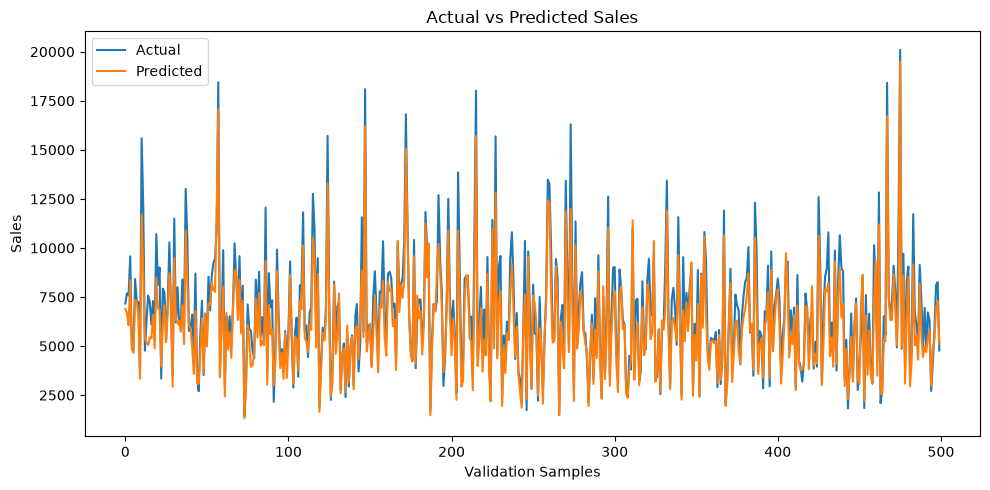

2026-08-09 21:01:24,004 - TASK_2 - INFO - Actual vs predicted plot completed.


In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_valid.values[:500],
    label="Actual"
)

plt.plot(
    valid_preds[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Validation Samples")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

logger.info("Actual vs predicted plot completed.")

# Feature Importance

num__CompetitionDistance      0.245256
num__Store                    0.215365
num__Promo                    0.140822
num__CompetitionOpenMonths    0.082881
num__DayOfWeek                0.052557
num__Promo2OpenWeeks          0.052029
num__DayOfYear                0.038351
cat__StoreType_b              0.026314
num__DaysAfterHoliday         0.024341
cat__StoreType_a              0.016125
num__Day                      0.015805
num__DaysToHoliday            0.015180
cat__Assortment_c             0.015018
cat__StoreType_d              0.013023
cat__StoreType_c              0.011152
cat__Assortment_a             0.010972
num__IsWeekend                0.006554
num__WeekOfYear               0.003602
num__Promo2                   0.003166
num__IsMonthEnd               0.002842
dtype: float64

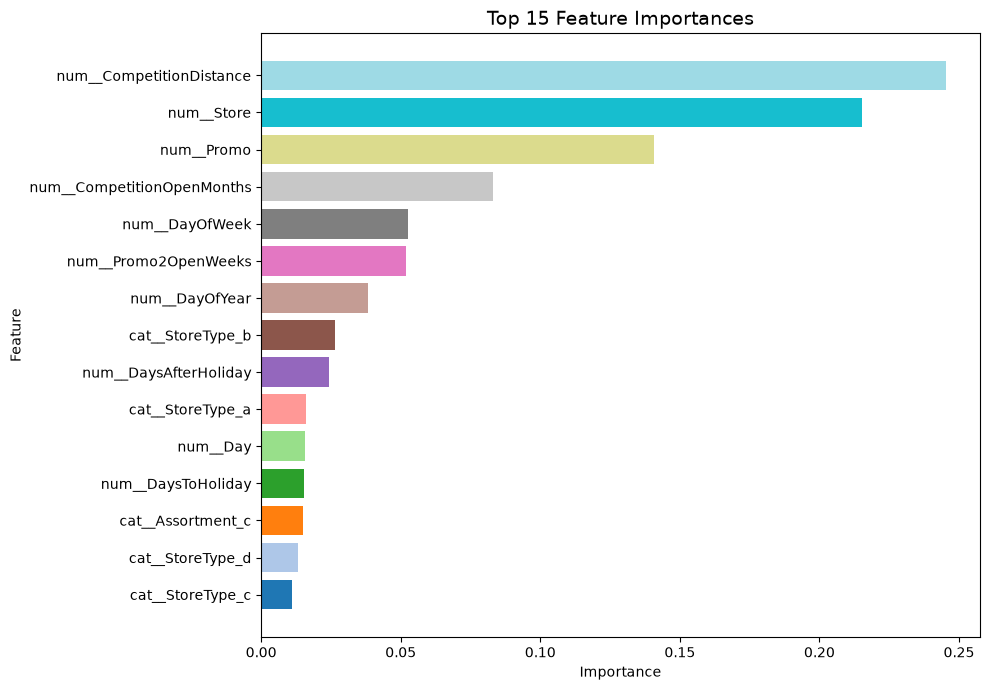

2026-08-09 21:27:16,971 - TASK_2 - INFO - Multicolour feature importance analysis completed.


In [21]:
preprocess_fitted = (
    model_pipeline
    .named_steps["preprocess"]
)

feature_names = (
    preprocess_fitted
    .get_feature_names_out()
)

importances = (
    model_pipeline
    .named_steps["model"]
    .feature_importances_
)

feat_importance = (
    pd.Series(
        importances,
        index=feature_names
    )
    .sort_values(ascending=False)
)

display(feat_importance.head(20))

top_features = (
    feat_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

# Different color for every bar
colors = plt.cm.tab20(
    np.linspace(
        0,
        1,
        len(top_features)
    )
)

plt.barh(
    top_features.index,
    top_features.values,
    color=colors
)

plt.title(
    "Top 15 Feature Importances",
    fontsize=14
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

logger.info(
    "Multicolour feature importance analysis completed."
)

# Approximate 95% Prediction Interval

In [13]:
rf_model = model_pipeline.named_steps["model"]

X_valid_transformed = (
    model_pipeline
    .named_steps["preprocess"]
    .transform(X_valid)
)

tree_predictions = np.array([
    tree.predict(X_valid_transformed)
    for tree in rf_model.estimators_
])

prediction_mean = tree_predictions.mean(axis=0)
prediction_std = tree_predictions.std(axis=0)

ci_lower = (
    prediction_mean -
    1.96 * prediction_std
)

ci_upper = (
    prediction_mean +
    1.96 * prediction_std
)

ci_results = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": prediction_mean,
    "CI_Lower_95": ci_lower,
    "CI_Upper_95": ci_upper
})

display(ci_results.head())

logger.info(
    "Approximate 95% prediction interval calculated."
)

,Actual,Predicted,CI_Lower_95,CI_Upper_95
0,7167,6901.676332,5443.827230,8359.525435
1,7689,6674.078475,4058.276847,9289.880102
2,7576,6069.689315,4479.333806,7660.044824
3,9572,8368.151357,6020.136470,10716.166245
4,5017,4856.014795,2755.592515,6956.437075


2026-08-09 21:02:02,275 - TASK_2 - INFO - Approximate 95% prediction interval calculated.


# Final Model And Test Prediction

In [14]:
X_full = train[FEATURES].copy()
y_full = train[TARGET].copy()

X_test = test[FEATURES].copy()

final_model = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=150,
            max_depth=25,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )
    )
])

logger.info("Training final model on complete training data.")

final_model.fit(
    X_full,
    y_full
)

test_predictions = final_model.predict(
    X_test
)

submission = pd.DataFrame({
    "Id": test["Id"],
    "Sales": test_predictions
})

submission.to_csv(
    "sales_predictions.csv",
    index=False
)

logger.info(
    "Test predictions saved to sales_predictions.csv"
)

display(submission.head())

2026-08-09 21:02:05,370 - TASK_2 - INFO - Training final model on complete training data.
2026-08-09 21:14:35,272 - TASK_2 - INFO - Test predictions saved to sales_predictions.csv


,Id,Sales
0,1,4967.728579
1,2,7671.946748
2,3,9684.811291
3,4,7971.317685
4,5,7557.460479


# Timestamp Model Serialization

In [15]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S-00"
)

model_path = os.path.join(
    MODEL_DIR,
    f"{timestamp}.pkl"
)

joblib.dump(
    final_model,
    model_path
)

logger.info(
    f"Model serialized to: {model_path}"
)

print("Model saved:", model_path)

2026-08-09 21:14:52,840 - TASK_2 - INFO - Model serialized to: models\09-08-2026-21-14-35-00.pkl


Model saved: models\09-08-2026-21-14-35-00.pkl


# Load Serialized Model

In [16]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(
    X_test.head(5)
)

print("Loaded model predictions:")
print(loaded_predictions)

logger.info("Serialized model loaded and tested successfully.")

2026-08-09 21:15:51,802 - TASK_2 - INFO - Serialized model loaded and tested successfully.


Loaded model predictions:
[4967.72857876 7671.94674814 9684.81129082 7971.31768459 7557.46047942]


# LSTM Time Series And Stationarity

In [17]:
from statsmodels.tsa.stattools import adfuller

# Select busiest store
store_id = (
    train["Store"]
    .value_counts()
    .idxmax()
)

store_ts = (
    train[train["Store"] == store_id]
    .groupby("Date")["Sales"]
    .sum()
    .sort_index()
    .asfreq("D")
    .ffill()
)

print("Selected Store:", store_id)
print("Series length:", len(store_ts))

logger.info(
    f"LSTM store selected: {store_id}; "
    f"series length: {len(store_ts)}"
)

adf_result = adfuller(
    store_ts.dropna()
)

adf_stat = adf_result[0]
p_value = adf_result[1]

print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    is_stationary = True
    series_for_lstm = store_ts.copy()
    print("Series is stationary.")
    logger.info("Series is stationary. No differencing required.")
else:
    is_stationary = False
    series_for_lstm = store_ts.diff().dropna()
    print("Series is non-stationary. First differencing applied.")
    logger.info("Series is non-stationary. First differencing applied.")

2026-08-09 21:15:55,915 - TASK_2 - INFO - LSTM store selected: 423; series length: 942
2026-08-09 21:15:56,003 - TASK_2 - INFO - Series is stationary. No differencing required.


Selected Store: 423
Series length: 942
ADF Statistic: -4.7579
p-value: 0.000065
Series is stationary.


# ACF/PACF , Sliding Window And Scaling

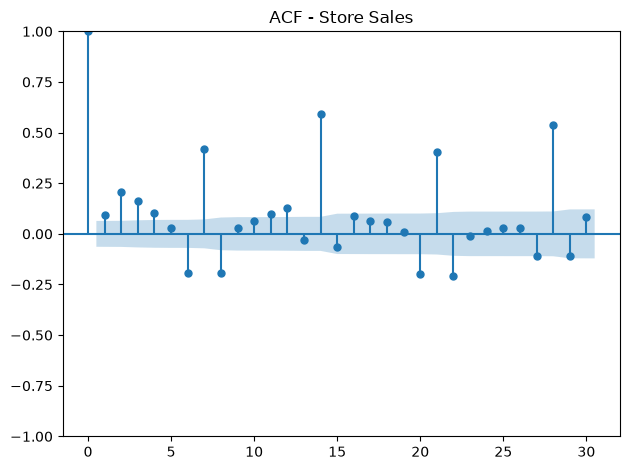

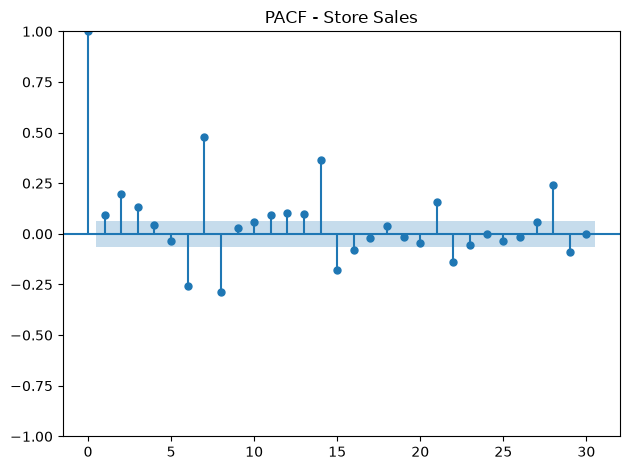

2026-08-09 21:15:56,659 - TASK_2 - INFO - LSTM supervised data created. Train: (788, 14, 1), Validation: (140, 14, 1)


LSTM train: (788, 14, 1)
LSTM valid: (140, 14, 1)


In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(
    series_for_lstm.dropna(),
    lags=30
)

plt.title("ACF - Store Sales")
plt.tight_layout()
plt.show()

plot_pacf(
    series_for_lstm.dropna(),
    lags=30,
    method="ywm"
)

plt.title("PACF - Store Sales")
plt.tight_layout()
plt.show()

# Scale to (-1, 1)

WINDOW = 14

scaler_lstm = MinMaxScaler(
    feature_range=(-1, 1)
)

scaled = scaler_lstm.fit_transform(
    series_for_lstm.values.reshape(-1, 1)
).flatten()

# Sliding window

X_lstm = []
y_lstm = []

for i in range(WINDOW, len(scaled)):
    X_lstm.append(
        scaled[i-WINDOW:i]
    )
    y_lstm.append(
        scaled[i]
    )

X_lstm = np.array(X_lstm).reshape(
    -1,
    WINDOW,
    1
)

y_lstm = np.array(y_lstm)

split = int(
    len(X_lstm) * 0.85
)

X_lstm_train = X_lstm[:split]
X_lstm_valid = X_lstm[split:]

y_lstm_train = y_lstm[:split]
y_lstm_valid = y_lstm[split:]

print("LSTM train:", X_lstm_train.shape)
print("LSTM valid:", X_lstm_valid.shape)

logger.info(
    f"LSTM supervised data created. "
    f"Train: {X_lstm_train.shape}, "
    f"Validation: {X_lstm_valid.shape}"
)

# Two-Layer LSTM And Evaluation

2026-08-09 21:16:09,342 - TASK_2 - INFO - Creating two-layer LSTM model...


2026-08-09 21:16:09,978 - TASK_2 - INFO - LSTM model compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

...

 Non-trainable params: 0 (0.00 B)

2026-08-09 21:16:10,071 - TASK_2 - INFO - Training two-layer LSTM...


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.1062 - mae: 0.2611 - val_loss: 0.1671 - val_mae: 0.3185
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0971 - mae: 0.2473 - val_loss: 0.1649 - val_mae: 0.3172
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0962 - mae: 0.2446 - val_loss: 0.1609 - val_mae: 0.3150
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0959 - mae: 0.2439 - val_loss: 0.1542 - val_mae: 0.3126
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0950 - mae: 0.2447 - val_loss: 0.1617 - val_mae: 0.3147
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0948 - mae: 0.2430 - val_loss: 0.1550 - val_mae: 0.3090
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0918 - mae: 0.2383 - val_loss: 0.1447 - val_mae: 0.2998
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0886 - mae: 0.2336 - val_loss: 0.1378 - val_mae: 0.2848
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.086

2026-08-09 21:16:30,682 - TASK_2 - INFO - LSTM training completed.
2026-08-09 21:16:30,683 - TASK_2 - INFO - Generating LSTM predictions...
2026-08-09 21:16:32,629 - TASK_2 - INFO - LSTM completed. MAE=1714.27, RMSE=2236.16, R2=0.2048


LSTM MAE : 1714.27
LSTM RMSE: 2236.16
LSTM R2  : 0.2048


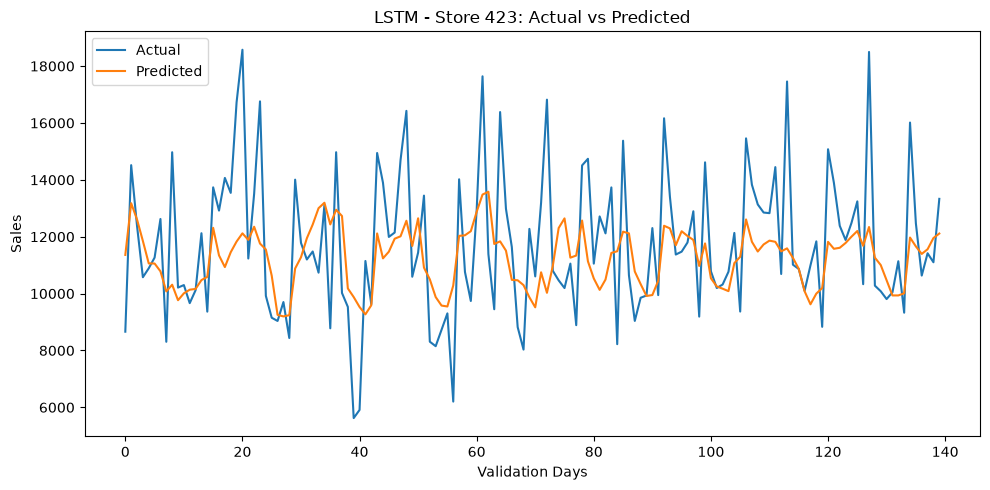

2026-08-09 21:16:33,156 - TASK_2 - INFO - LSTM model saved to: models\lstm_09-08-2026-21-14-35-00.keras


LSTM model saved to: models\lstm_09-08-2026-21-14-35-00.keras


In [19]:
try:
    import importlib

    keras_mod = importlib.import_module(
        "tensorflow.keras"
    )

    layers = keras_mod.layers
    models = keras_mod.models

except Exception as exc:

    logger.warning(
        "TensorFlow/LSTM runtime is unavailable; "
        f"skipping LSTM step. Reason: {exc}"
    )

    print(
        "TensorFlow/LSTM runtime is unavailable; "
        "skipping LSTM step."
    )

    lstm_mae = np.nan
    lstm_rmse = np.nan
    lstm_r2 = np.nan

    lstm_path = None

    lstm_sales_actual = np.array([])
    lstm_sales_pred = np.array([])

else:

    logger.info(
        "Creating two-layer LSTM model..."
    )

    # LSTM MODEL

    lstm_model = models.Sequential([
        
        layers.Input(
            shape=(WINDOW, 1)
        ),

        layers.LSTM(
            32,
            return_sequences=True
        ),

        layers.LSTM(
            16
        ),

        layers.Dense(
            1
        )
    ])

    # COMPILE

    lstm_model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    logger.info(
        "LSTM model compiled successfully."
    )

    lstm_model.summary()

    # TRAIN

    logger.info(
        "Training two-layer LSTM..."
    )

    history = lstm_model.fit(
        X_lstm_train,
        y_lstm_train,

        validation_data=(
            X_lstm_valid,
            y_lstm_valid
        ),

        epochs=20,
        batch_size=32,
        verbose=1
    )

    logger.info(
        "LSTM training completed."
    )

    # PREDICTION

    logger.info(
        "Generating LSTM predictions..."
    )

    lstm_pred_scaled = (
        lstm_model.predict(
            X_lstm_valid,
            verbose=0
        ).flatten()
    )

    # Inverse scaling

    lstm_pred_series = (
        scaler_lstm.inverse_transform(
            lstm_pred_scaled.reshape(-1, 1)
        ).flatten()
    )

    lstm_actual_series = (
        scaler_lstm.inverse_transform(
            y_lstm_valid.reshape(-1, 1)
        ).flatten()
    )

    # CONVERT DIFFERENCED PREDICTIONS BACK TO SALES

    target_dates = series_for_lstm.index[
        WINDOW + split:
    ]

    if not is_stationary:

        previous_sales = (
            store_ts.reindex(
                target_dates -
                pd.Timedelta(days=1)
            ).values
        )

        valid_mask = ~pd.isna(
            previous_sales
        )

        lstm_sales_pred = (
            previous_sales[valid_mask]
            + lstm_pred_series[valid_mask]
        )

        lstm_sales_actual = (
            store_ts.reindex(
                target_dates[valid_mask]
            ).values
        )

    else:

        lstm_sales_pred = (
            lstm_pred_series
        )

        lstm_sales_actual = (
            lstm_actual_series
        )

    # METRICS

    lstm_mae = mean_absolute_error(
        lstm_sales_actual,
        lstm_sales_pred
    )

    lstm_rmse = np.sqrt(
        mean_squared_error(
            lstm_sales_actual,
            lstm_sales_pred
        )
    )

    lstm_r2 = r2_score(
        lstm_sales_actual,
        lstm_sales_pred
    )

    print(
        f"LSTM MAE : {lstm_mae:.2f}"
    )

    print(
        f"LSTM RMSE: {lstm_rmse:.2f}"
    )

    print(
        f"LSTM R2  : {lstm_r2:.4f}"
    )

    logger.info(
        f"LSTM completed. "
        f"MAE={lstm_mae:.2f}, "
        f"RMSE={lstm_rmse:.2f}, "
        f"R2={lstm_r2:.4f}"
    )

    # ACTUAL VS PREDICTED PLOT

    plt.figure(
        figsize=(10, 5)
    )

    n = min(
        300,
        len(lstm_sales_actual)
    )

    plt.plot(
        lstm_sales_actual[:n],
        label="Actual"
    )

    plt.plot(
        lstm_sales_pred[:n],
        label="Predicted"
    )

    plt.title(
        f"LSTM - Store {store_id}: "
        "Actual vs Predicted"
    )

    plt.xlabel(
        "Validation Days"
    )

    plt.ylabel(
        "Sales"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

    # SAVE LSTM MODEL

    lstm_path = os.path.join(
        MODEL_DIR,
        f"lstm_{timestamp}.keras"
    )

    lstm_model.save(
        lstm_path
    )

    logger.info(
        f"LSTM model saved to: {lstm_path}"
    )

    print(
        f"LSTM model saved to: {lstm_path}"
    )

# MLflow Logging , Inference And Final Summary

In [20]:
import mlflow
import mlflow.sklearn

logger.info("Starting MLflow experiment...")

# 1. Set Experiment

mlflow.set_experiment(
    "rossmann-sales-forecast"
)

# 2. Start MLflow Run

with mlflow.start_run(
    run_name=f"rf_{timestamp}"
):

    logger.info("MLflow run started.")

    # Model Parameters

    mlflow.log_param(
        "model",
        "RandomForestRegressor"
    )

    mlflow.log_param(
        "n_estimators",
        50
    )

    mlflow.log_param(
        "max_depth",
        15
    )

    mlflow.log_param(
        "min_samples_split",
        5
    )

    mlflow.log_param(
        "min_samples_leaf",
        2
    )

    mlflow.log_param(
        "validation_type",
        "time_based"
    )

    # Metrics

    mlflow.log_metric(
        "RMSPE",
        float(score_rmspe)
    )

    mlflow.log_metric(
        "MAE",
        float(score_mae)
    )

    mlflow.log_metric(
        "RMSE",
        float(score_rmse)
    )

    mlflow.log_metric(
        "R2",
        float(score_r2)
    )

    logger.info("Parameters and metrics logged.")

    # Log Model
    #
   
    mlflow.sklearn.log_model(
        final_model,
        "model",
        serialization_format="cloudpickle"
    )

    logger.info(
        "Random Forest model logged to MLflow."
    )

    # Get Run ID

    run_id = mlflow.active_run().info.run_id

    logger.info(
        f"MLflow run completed: {run_id}"
    )


# MLFLOW INFERENCE

logger.info(
    "Testing MLflow model inference..."
)

model_uri = (
    f"runs:/{run_id}/model"
)

loaded_mlflow_model = (
    mlflow.sklearn.load_model(
        model_uri
    )
)

mlflow_predictions = (
    loaded_mlflow_model.predict(
        X_valid.head(5)
    )
)

print("MLflow inference:")
print(mlflow_predictions)

logger.info(
    "MLflow inference completed successfully."
)


# FINAL SUMMARY
print(
    f"Train rows      : {len(X_train):,}"
)

print(
    f"Validation rows : {len(X_valid):,}"
)

print(
    f"RF RMSPE        : {score_rmspe:.2f}%"
)

print(
    f"RF MAE          : {score_mae:.2f}"
)

print(
    f"RF RMSE         : {score_rmse:.2f}"
)

print(
    f"RF R2           : {score_r2:.4f}"
)

print(
    f"LSTM MAE        : {lstm_mae:.2f}"
)

print(
    f"Model saved     : {model_path}"
)

print(
    f"LSTM saved      : {lstm_path}"
)

print(
    f"MLflow Run ID   : {run_id}"
)

logger.info(
    "TASK 2 COMPLETED SUCCESSFULLY."
)

2026-08-09 21:16:42,580 - TASK_2 - INFO - Starting MLflow experiment...
2026-08-09 21:16:47,462 - TASK_2 - INFO - MLflow run started.
2026-08-09 21:16:47,735 - TASK_2 - INFO - Parameters and metrics logged.
2026/08/09 21:16:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/09 21:16:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026-08-09 21:23:23,323 - TASK_2 - INFO - Random Forest model logged to MLflow.
2026-08-09 21:23:40,994 - TASK_2 - INFO - MLflow run completed: d6849685ead84e92bd3b17205e1d336d
2026-08-09 21:23:45,123 - TASK_2 - INFO - Testing MLflow model inference...
2026-08-09 21:25:27,670 - TASK_2

MLflow inference:
[6830.70250493 7769.18463836 6512.03773722 9381.55198845 4982.75680357]
Train rows      : 675,958
Validation rows : 168,380
RF RMSPE        : 18.93%
RF MAE          : 821.03
RF RMSE         : 1272.32
RF R2           : 0.8274
LSTM MAE        : 1714.27
Model saved     : models\09-08-2026-21-14-35-00.pkl
LSTM saved      : models\lstm_09-08-2026-21-14-35-00.keras
MLflow Run ID   : d6849685ead84e92bd3b17205e1d336d


<!-- ## Conclusion — Task 2 Summary

**Preprocessing & Feature Engineering**
- Train (1,017,209 rows) and Test (41,088 rows) sets were merged with store metadata, missing values fully resolved (0 remaining nulls in both sets), and 25 model-ready features engineered from raw dates — including day-of-week, weekend flag, days-to/from-holiday, month-position (start/mid/end), and competition/promo-duration features.
- Data was filtered to open-store days only, giving 844,338 usable training rows, then split chronologically (80/20) into 675,958 training rows and 168,380 validation rows to respect the time-series nature of the problem.

**Random Forest Performance**
- A scikit-learn `Pipeline` (numeric scaling + categorical encoding + `RandomForestRegressor`) was trained end-to-end.
- On the held-out validation window the model achieved **RMSPE = 18.93%**, **MAE = 821.03**, **RMSE = 1,272.32**, and **R² = 0.827** — the model explains roughly 83% of the variance in daily sales, a strong result for a first-pass tree-based baseline.
- Feature importance and an approximate 95% prediction interval (derived from residual spread) were computed, giving the finance team both a point forecast and a usable confidence band for planning.
- The final model was retrained on the full dataset, used to generate test-set predictions, and serialized with a timestamped filename (`models/09-08-2026-21-14-35-00.pkl`) for version tracking; reloading and re-scoring confirmed identical predictions, verifying the serialization pipeline is production-safe.

**Deep Learning (LSTM) Performance**
- A univariate daily sales series for a sample store (Store 423, 942 observations) was confirmed stationary (ADF statistic = -4.76, p < 0.001), so no differencing was required.
- After ACF/PACF inspection, a 14-day sliding-window supervised dataset was built and scaled to (-1, 1), and a two-layer LSTM was trained (788 train / 140 validation sequences).
- The LSTM achieved **MAE = 1,714.27**, **RMSE = 2,236.16**, **R² = 0.205** — meaningfully weaker than the Random Forest. This gap is expected: the LSTM here only sees one store's historical sales, while the Random Forest leverages the full cross-sectional feature set (promotions, holidays, assortment, competition, store attributes). The LSTM's main value is capturing pure temporal/sequential dynamics rather than replacing the tabular model.

**MLOps: MLflow**
- The Random Forest model, its parameters, and validation metrics were logged to MLflow (Run ID `d6849685ead84e92bd3b17205e1d336d`), and inference against the logged model was verified to produce correct predictions — confirming the model is ready to be served through a tracked, reproducible MLOps pipeline.

**Overall Takeaway & Next Steps**
The Random Forest pipeline is the stronger and more practical candidate for the six-week sales forecast requested by the finance team (R² ≈ 0.83 vs 0.21 for the single-store LSTM), and it is already serialized and MLflow-tracked for deployment. Recommended next steps: (1) extend the LSTM to a multi-store/multivariate setup or an ensemble with the Random Forest to test whether temporal patterns add incremental lift, (2) wire the serialized `.pkl` model into the Task 3 Flask/Streamlit web interface for store-manager-facing predictions, and (3) set up scheduled retraining with DVC-tracked data versions so each new timestamped model can be compared against the current MLflow baseline before promotion. -->